<a href="https://colab.research.google.com/github/CaioPedroF/projeto-clustering-copa-mundo/blob/main/AVF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Título: Projeto Final - (Jogos/Esportes).

O objetivo deste projeto é agrupar as seleções nacionais da Copa do Mundo com base em seu desempenho histórico (ataque vs. defesa). Queremos identificar quais países formam a "Elite Mundial", quais são "Competitivos" e quais são "Participantes". Isso ajudará o "CEO da FIFA" a entender onde investir em marketing e desenvolvimento técnico.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Carregar a base fornecida [cite: 32]
df = pd.read_csv('wcmatches.csv')

# Visualização inicial para análise exploratória [cite: 12]
df.head()

,year,country,city,stage,home_team,away_team,home_score,away_score,outcome,win_conditions,winning_team,losing_team,date,month,dayofweek
0,1930,Uruguay,Montevideo,Group 1,France,Mexico,4,1,H,NaN,France,Mexico,1930-07-13,Jul,Sunday
1,1930,Uruguay,Montevideo,Group 4,Belgium,United States,0,3,A,NaN,United States,Belgium,1930-07-13,Jul,Sunday
2,1930,Uruguay,Montevideo,Group 2,Brazil,Yugoslavia,1,2,A,NaN,Yugoslavia,Brazil,1930-07-14,Jul,Monday
3,1930,Uruguay,Montevideo,Group 3,Peru,Romania,1,3,A,NaN,Romania,Peru,1930-07-14,Jul,Monday
4,1930,Uruguay,Montevideo,Group 1,Argentina,France,1,0,H,NaN,Argentina,France,1930-07-15,Jul,Tuesday


Análise Exploratória e Pré-processamento

In [3]:
# Criando métricas por equipe (Mandante)
home_stats = df.groupby('home_team').agg({'home_score': 'sum', 'away_score': 'sum', 'year': 'count'})
# Criando métricas por equipe (Visitante)
away_stats = df.groupby('away_team').agg({'away_score': 'sum', 'home_score': 'sum', 'year': 'count'})

# Consolidando (Gols Pró, Gols Contra, Partidas)
stats = home_stats.add(away_stats, fill_value=0)
stats.columns = ['gols_feitos', 'gols_sofridos', 'total_partidas']
stats['media_gols'] = stats['gols_feitos'] / stats['total_partidas']

# Justificativa: Normalizei os dados pois o K-Means é sensível à escala [cite: 29, 31]
scaler = StandardScaler()
dados_scaled = scaler.fit_transform(stats[['gols_feitos', 'media_gols']])

Construção e Avaliação dos Clusters:
Utilizei o K-Means por ser o algoritmo de partição mais robusto para identificar grupos de desempenho similares em esportes.

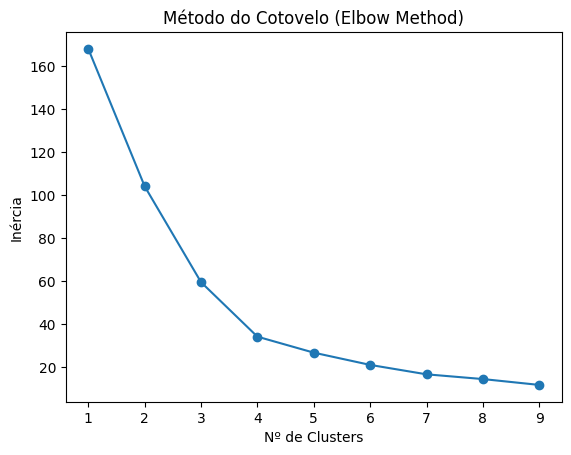

Coeficiente Silhouette: 0.50


In [4]:
# Método do Cotovelo para definir o número de clusters [cite: 18]
inercias = []
for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(dados_scaled)
    inercias.append(model.inertia_)

plt.plot(range(1, 10), inercias, marker='o')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Nº de Clusters')
plt.ylabel('Inércia')
plt.show()

# Aplicando o modelo final (ex: k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
stats['cluster'] = kmeans.fit_predict(dados_scaled)

# Métrica de Qualidade [cite: 18]
score = silhouette_score(dados_scaled, stats['cluster'])
print(f"Coeficiente Silhouette: {score:.2f}")

Descrição Detalhada dos Grupos

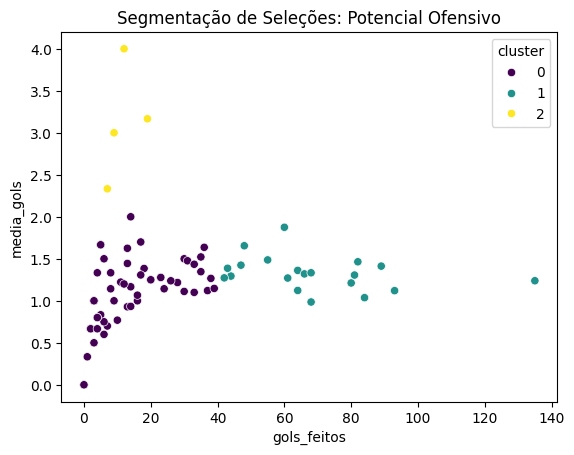

         gols_feitos  gols_sofridos  total_partidas  media_gols
cluster                                                        
0          14.183333      17.666667           11.90    1.094830
1          68.700000      87.500000           53.55    1.329032
2          11.750000       3.500000            3.75    3.125000


In [5]:
sns.scatterplot(data=stats, x='gols_feitos', y='media_gols', hue='cluster', palette='viridis')
plt.title('Segmentação de Seleções: Potencial Ofensivo')
plt.show()

# Perfil dos Clusters [cite: 20]
print(stats.groupby('cluster').mean())